In [2]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1014. Nanoparticles Respiratory Tract/P1014.3. Analyses/P1014.3.2. Volcano Plots/Output'
cur_date = '051426'

library(readxl)
library(openxlsx)
library(writexl)
library(tidyverse)
library(ggrepel)
library(ggsci)
library(ggh4x)
library(cowplot)

# reading in files
two_group_df = data.frame(read_excel("Input/Two_Group_Results_051426.xlsx"))  

In [3]:
head(two_group_df)

,UniProt_ID,ELISA_ID,Protein_Name,Comparison,log2FC,P.Value,P.Adj
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,P10909,nEL03731,CLU,Control vs. PET 0.05mg/mL,-2.7972194,4.265773e-12,1.202948e-09
2,O00300,nEL04021,TNFRSF11B,Control vs. PET 0.05mg/mL,-2.5704628,6.488379e-10,9.148614e-08
3,P10147,nEL00061,CCL3,Control vs. PET 0.05mg/mL,1.5703907,6.923073e-09,6.507689e-07
4,Q99988,nEL01981,GDF-15 (MIC-1),Control vs. PET 0.05mg/mL,1.0168714,1.149077e-05,8.100993e-04
5,Q9H2A7,nEL00441,CXCL16,Control vs. PET 0.05mg/mL,-0.8511750,1.456932e-05,8.217095e-04
6,Q99538,nEL08971,LGMN,Control vs. PET 0.05mg/mL,-0.7562914,3.048368e-05,1.432733e-03


Creating a volcano plot to differences in protein expression after exposure to phthalates and nylon.

In [4]:
get_significance = function(df){
    # adding a col to denote whether a protein had a significant p value, log FC, or both
    
    # add a column of NAs
    df$diffexpressed <- "No Significance"
    
    # if p adj is significant only
    df$diffexpressed[df$P.Adj < 0.05] <- "Significant"#"P Adjust Only"
    
    # if logFoldChange > log2(1.5) and p adj < 0.05, set as "significant" 
    #df$diffexpressed[abs(df$log2FC) > log2(1.5) & df$P.Adj < 0.05] <- "P Adjust and log Fold Change"
    
    # making into a factor
    df$diffexpressed = factor(df$diffexpressed, levels = c("No Significance", "Significant"))#"P Adjust Only", 
                                                                           #"P Adjust and log Fold Change"))

    return(df)
}

# calling fn
two_sig_protein_df = get_significance(two_group_df)
two_sig_protein_df = two_sig_protein_df %>%
    mutate(Comparison = ifelse(Comparison == 'Control vs. PET 0.05mg/mL', '(A) Control vs. PET 0.05mg/mL',
                            ifelse(Comparison == 'Control vs. PET 0.1mg/mL', '(B) Control vs. PET 0.1mg/mL',
                               ifelse(Comparison == 'PET 0.05mg/mL vs. PET 0.1mg/mL', '(C) PET 0.05mg/mL vs. PET 0.1mg/mL',
                                   ifelse(Comparison == 'Control vs. PET-Rhodamine B 0.05mg/mL', '(D) Control vs. PET-Rhodamine B 0.05mg/mL',
                                       ifelse(Comparison == 'Control vs. PET-Rhodamine B 0.1mg/mL', '(E) Control vs. PET-Rhodamine B 0.1mg/mL',
                                           ifelse( Comparison == 'PET-Rhodamine B 0.05mg/mL vs.\nPET-Rhodamine B 0.1mg/mL', 
                               '(F) PET-Rhodamine B 0.05mg/mL vs.\nPET-Rhodamine B 0.1mg/mL', Comparison)))))))
two_sig_protein_df$Comparison = factor(two_sig_protein_df$Comparison, 
                                       levels = c('(A) Control vs. PET 0.05mg/mL','(B) Control vs. PET 0.1mg/mL',
                                                  '(C) PET 0.05mg/mL vs. PET 0.1mg/mL', '(D) Control vs. PET-Rhodamine B 0.05mg/mL',
                                                  '(E) Control vs. PET-Rhodamine B 0.1mg/mL', 
                                                  '(F) PET-Rhodamine B 0.05mg/mL vs.\nPET-Rhodamine B 0.1mg/mL'))

head(two_sig_protein_df)

,UniProt_ID,ELISA_ID,Protein_Name,Comparison,log2FC,P.Value,P.Adj,diffexpressed
,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<fct>
1,P10909,nEL03731,CLU,(A) Control vs. PET 0.05mg/mL,-2.7972194,4.265773e-12,1.202948e-09,Significant
2,O00300,nEL04021,TNFRSF11B,(A) Control vs. PET 0.05mg/mL,-2.5704628,6.488379e-10,9.148614e-08,Significant
3,P10147,nEL00061,CCL3,(A) Control vs. PET 0.05mg/mL,1.5703907,6.923073e-09,6.507689e-07,Significant
4,Q99988,nEL01981,GDF-15 (MIC-1),(A) Control vs. PET 0.05mg/mL,1.0168714,1.149077e-05,8.100993e-04,Significant
5,Q9H2A7,nEL00441,CXCL16,(A) Control vs. PET 0.05mg/mL,-0.8511750,1.456932e-05,8.217095e-04,Significant
6,Q99538,nEL08971,LGMN,(A) Control vs. PET 0.05mg/mL,-0.7562914,3.048368e-05,1.432733e-03,Significant


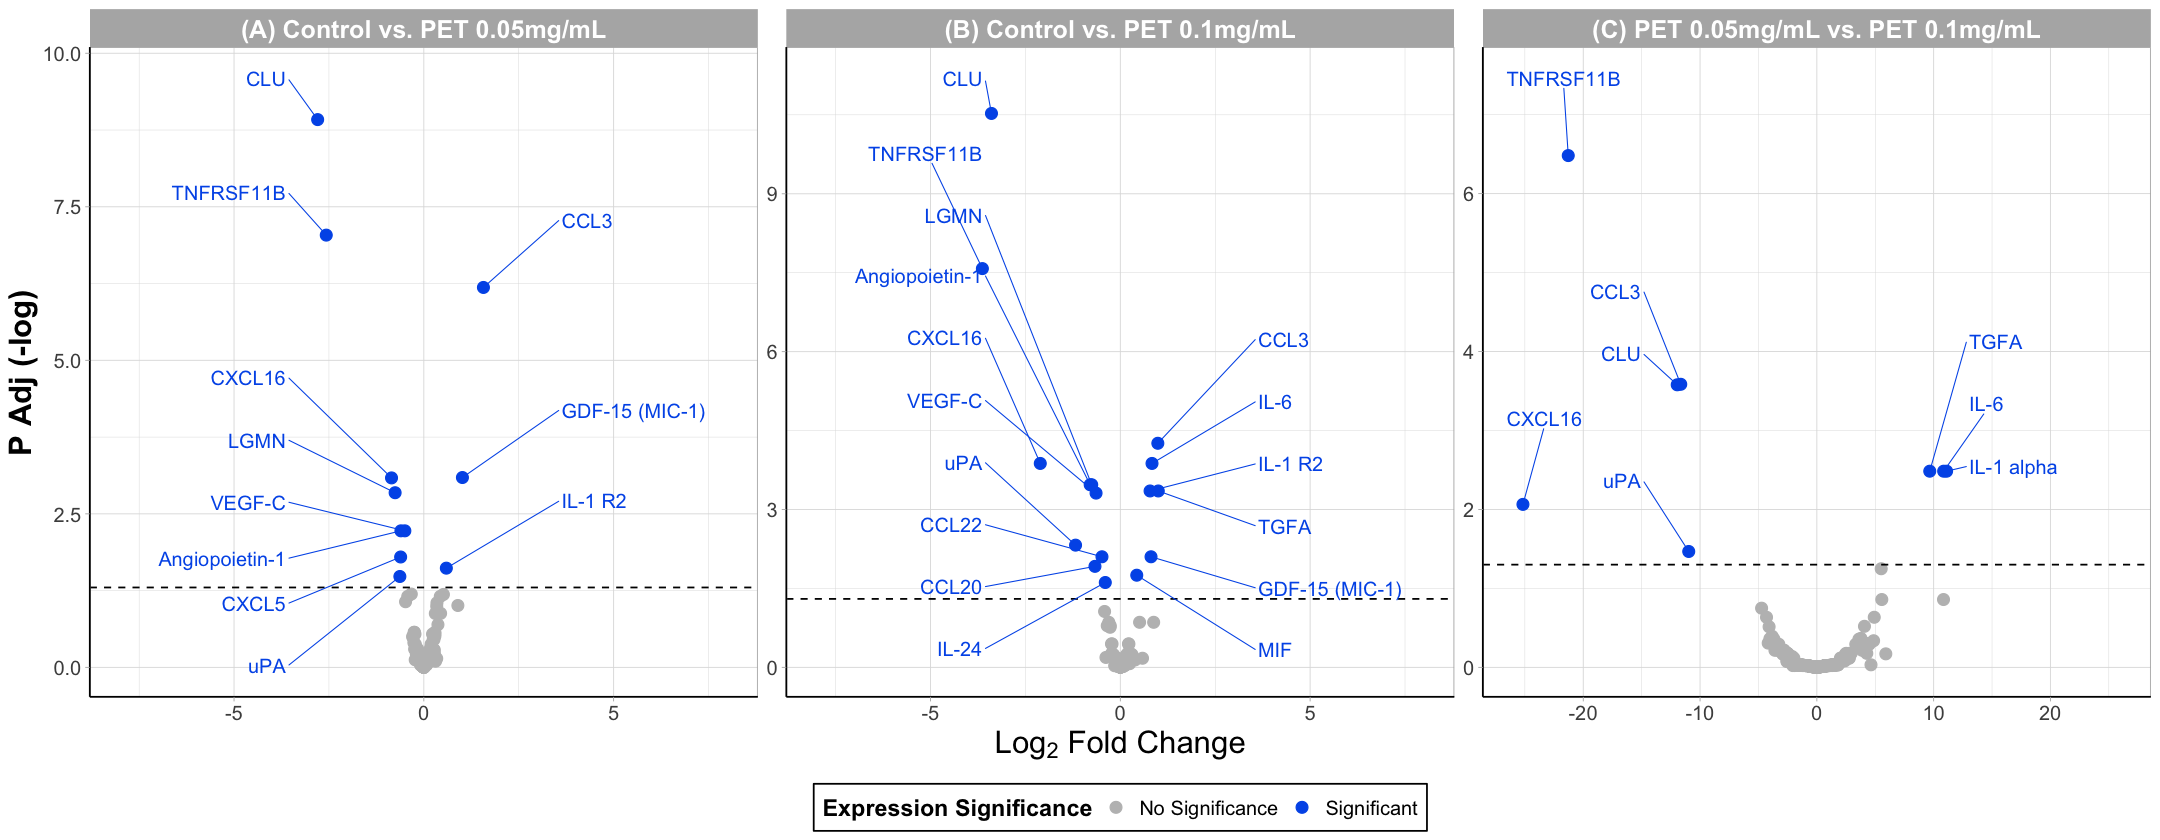

In [5]:
options(repr.plot.width=18, repr.plot.height=7) #changing size

lancet_palette = pal_lancet()(2)

FigureXa = ggplot() + 
  geom_point(data = two_sig_protein_df %>%
                 filter(!grepl('Rhodamine',Comparison)), aes(x = log2FC, y = -log10(P.Adj), color = diffexpressed), size = 3) + 

  # P Value line
  geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
  # # FC Line
  # geom_vline(xintercept = log2(1.5), linetype = "dashed") +
  # geom_vline(xintercept = -log2(1.5), linetype = "dashed") +

  geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC > 0, P.Adj < 0.05, !grepl('Rhodamine',Comparison), grepl('Control',Comparison)), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed),
                  hjust = 'right', direction = 'y', nudge_y = 1.1, nudge_x = 0.03, xlim = c(3, NA), 
                  segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 
 geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC < 0 , P.Adj < 0.05, !grepl('Rhodamine',Comparison), grepl('Control',Comparison)), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'left', direction = 'y', nudge_y = 0.7, nudge_x = -0.03, xlim = c(NA, -3), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 
 geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC < 0, P.Adj < 0.05, !grepl('Rhodamine',Comparison), !grepl('Control',Comparison)), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'right', direction = 'y', nudge_y = 1, nudge_x = -0.03, xlim = c(NA, -13), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 
 geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC > 0, P.Adj < 0.05, !grepl('Rhodamine',Comparison), !grepl('Control',Comparison)), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'right', direction = 'y', nudge_y = 1.2, nudge_x = -0.03, xlim = c(11, NA), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

  facet_wrap(~Comparison, scales = 'free') + 
  facetted_pos_scales(x = list(
      Comparison == '(A) Control vs. PET 0.05mg/mL' ~ scale_x_continuous(limits = c(-8, 8)),
      Comparison == '(B) Control vs. PET 0.1mg/mL' ~ scale_x_continuous(limits = c(-8, 8)),
      Comparison == '(C) PET 0.05mg/mL vs. PET 0.1mg/mL' ~ scale_x_continuous(limits = c(-26, 26)))) + 

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        axis.title = element_text(face = "bold", size = rel(1.7)), #changes axis titles
        legend.title = element_text(face = 'bold', size = 14), #changes legend title
        legend.text = element_text(size = 12), #changes legend text
        legend.position = "bottom", # changing legend position
        legend.background = element_rect(colour = 'black', fill = 'white', linetype = 'solid'),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes size of facet y axis 
  labs(x = expression(Log[2]*" Fold Change"), y = 'P Adj (-log)') +

  scale_color_manual(name = "Expression Significance",
                      values = c("gray", "#005BEA",'#F0D25E', "#005BEA"))

FigureXa

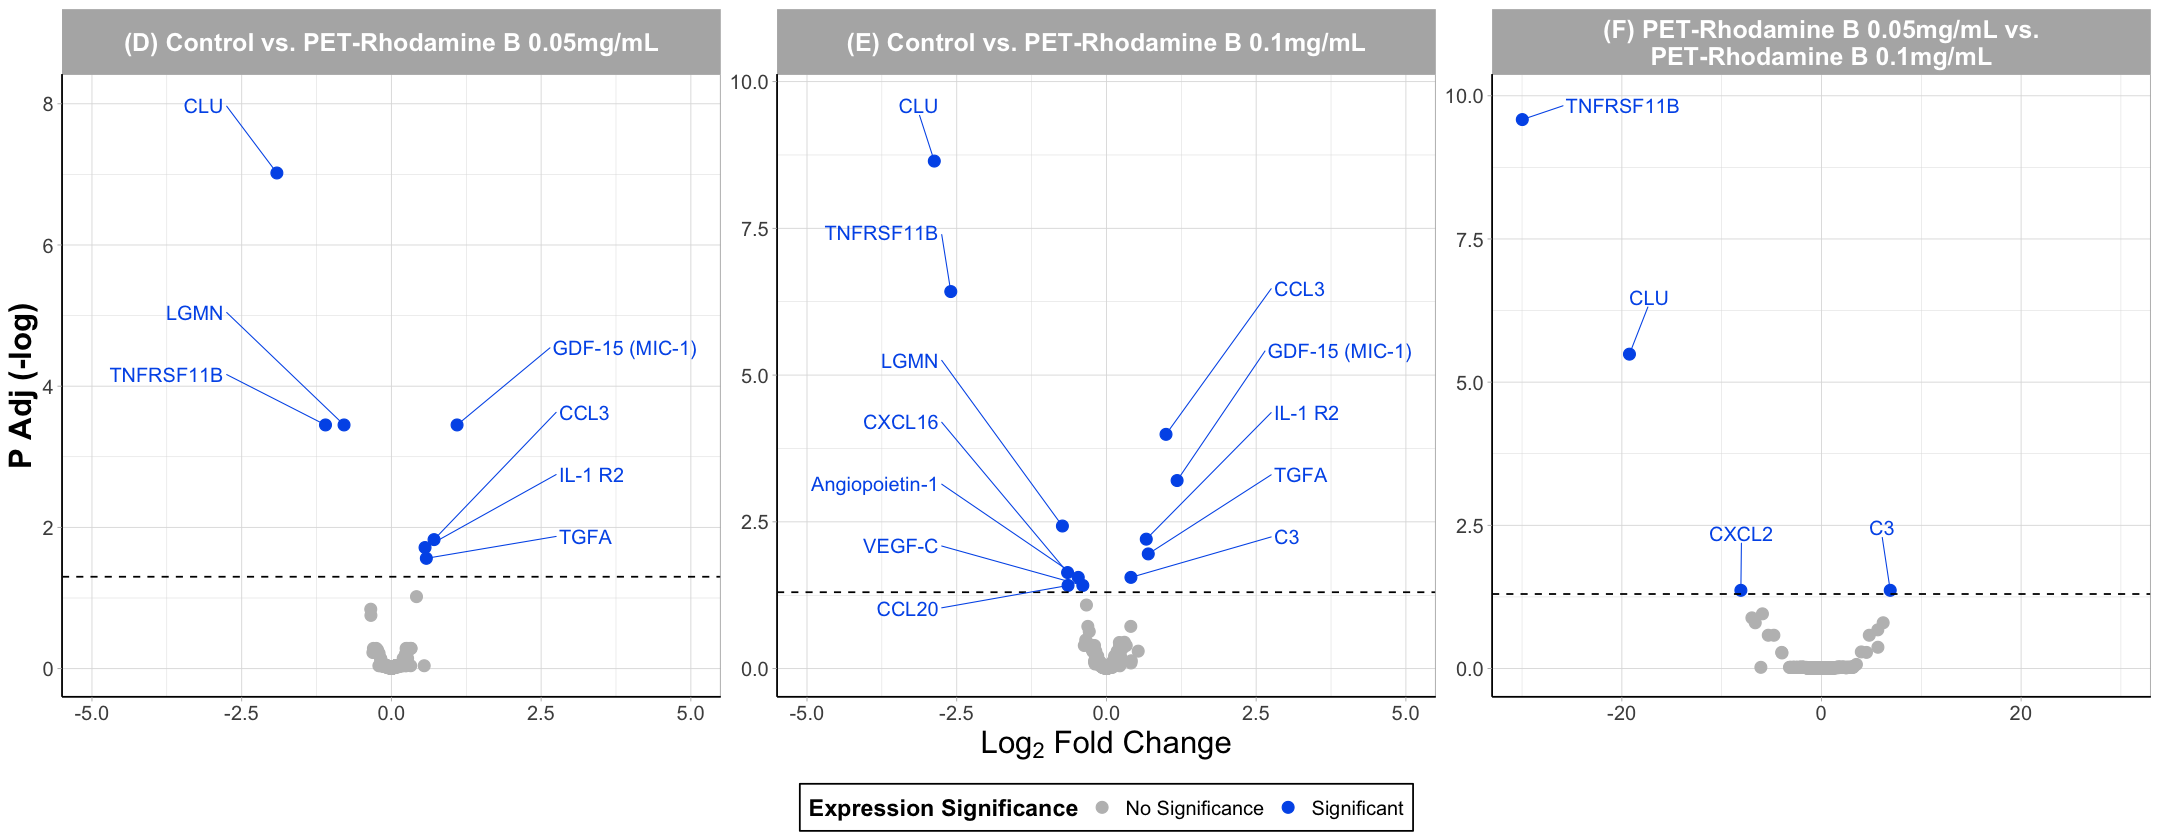

In [6]:
FigureXb = ggplot() + 
  geom_point(data = two_sig_protein_df %>%
                 filter(grepl('Rhodamine',Comparison)), aes(x = log2FC, y = -log10(P.Adj), color = diffexpressed), size = 3) + 

  # P Value line
  geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
  # # FC Line
  # geom_vline(xintercept = log2(1.5), linetype = "dashed") +
  # geom_vline(xintercept = -log2(1.5), linetype = "dashed") +

  # changing x limits of what is visible in the plot

  geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC > 0, P.Adj < 0.05, grepl('Rhodamine',Comparison)), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed),
                  hjust = 'right', direction = 'y', nudge_y = 1.1, nudge_x = 0.01, xlim = c(2.4, NA), 
                  segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 
 geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC < 0 & log2FC > -20, P.Adj < 0.05, grepl('Rhodamine',Comparison)), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'left', direction = 'y', nudge_y = 1, nudge_x = -0.01, xlim = c(NA, -2.4), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 
 geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC < -20, P.Adj < 0.05, grepl('Rhodamine',Comparison)), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'right', direction = 'y', nudge_y = 0.3, nudge_x = 5, xlim = c(-28, NA), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

  facet_wrap(~Comparison, scales = 'free') + 

  facetted_pos_scales(x = list(
      Comparison == '(D) Control vs. PET-Rhodamine B 0.05mg/mL' ~ scale_x_continuous(limits = c(-5, 5)),
      Comparison == '(E) Control vs. PET-Rhodamine B 0.1mg/mL' ~ scale_x_continuous(limits = c(-5, 5)),
      Comparison == '(F) PET-Rhodamine B 0.05mg/mL vs.\nPET-Rhodamine B 0.1mg/mL' ~ scale_x_continuous(limits = c(-30, 30)))) + 

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        axis.title = element_text(face = "bold", size = rel(1.7)), #changes axis titles
        legend.title = element_text(face = 'bold', size = 14), #changes legend title
        legend.text = element_text(size = 12), #changes legend text
        legend.position = "bottom", # changing legend position
        legend.background = element_rect(colour = 'black', fill = 'white', linetype = 'solid'),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes size of facet y axis 
  labs(x = expression(Log[2]*" Fold Change"), y = 'P Adj (-log)') +

  scale_color_manual(name = "Expression Significance",
                      values = c("gray", "#005BEA",'#F0D25E', "#005BEA"))

FigureXb

In [7]:
# options(repr.plot.width=18, repr.plot.height=14) #changing size
# FigureX = plot_grid(FigureXa, FigureXb, ncol = 1)
# FigureX